In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks
from scipy.interpolate import CubicSpline


Jumlah file PPG : 86
001_wean              R=0.4779  GT=99.0
002_Farid             R=0.4178  GT=99.0
003_Laviona           R=0.3901  GT=96.0
004_Dzawan            R=0.4173  GT=98.0
005_Rifha             R=0.4548  GT=98.0
006_Abel              R=0.3940  GT=99.0
007_Fina              R=1.4167  GT=99.0
007_Gracia            R=0.4417  GT=97.0
008_Farhat            R=0.4031  GT=98.0
009_Hizkia            R=1.3390  GT=98.0
009_Mumtaz            R=0.3968  GT=98.0
010_Amel              R=0.4174  GT=99.0
011_Azzura            R=0.4250  GT=99.0
012_Inne              R=0.4176  GT=96.0
013_Izza              R=1.3696  GT=97.0
014_kael              R=0.3803  GT=99.0
015_Nayla             R=0.4378  GT=99.0
015_Nayla             R=0.3891  GT=98.0
016_Olyvia            R=1.0672  GT=99.0
016_Olyvia            R=0.3977  GT=95.0
017_Alila             R=0.4320  GT=99.0
017_Alila             R=0.3601  GT=99.0
018_Darlene           R=0.5048  GT=96.0
019_Kevin             R=0.3622  GT=98.0
020_Riyu           

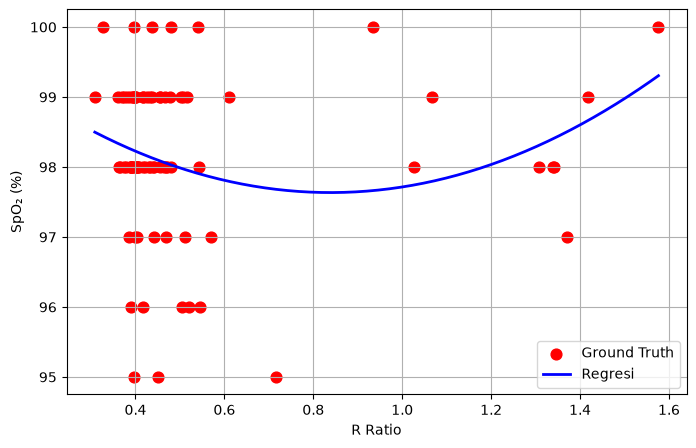

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import CubicSpline

# ==========================================================
# 1. Fungsi Preprocessing
# ==========================================================

def baseline_correction(time, x, fs):
    min_distance = int(0.5 * fs)
    peaks, _ = find_peaks(
        -x,
        distance=min_distance,
        prominence=0.1
    )
    if len(peaks) < 2:
        raise ValueError("Lembah terlalu sedikit")
    t_val = time[peaks]
    s_val = x[peaks]
    spline = CubicSpline(
        t_val,
        s_val,
        bc_type='natural'
    )
    baseline_dc = spline(time)
    corrected = x - baseline_dc
    return corrected, baseline_dc

def bpf(signal, low_cut=0.5, high_cut=10, fs=125, order=4):
    nyq = fs / 2
    b, a = butter(
        order,
        [low_cut/nyq, high_cut/nyq],
        btype='band'
    )
    return filtfilt(b, a, signal)

def calculate_ac_peak_to_peak(signal, fs, prominence=10):
    min_distance = int(0.5 * fs)
    peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )
    troughs, _ = find_peaks(
        -signal,
        distance=min_distance,
        prominence=prominence
    )
    n = min(len(peaks), len(troughs))
    if n == 0:
        return None
    amp = []

    for i in range(n):

        amp.append(
            signal[peaks[i]] -
            signal[troughs[i]]
        )

    return np.mean(amp)

# ==========================================================
# 2. Folder Dataset
# ==========================================================

DATASET_FOLDER = r"C:\Users\viona\Downloads\data_primer\data_primer"
PROMINENCE = 25
list_r = []
list_spo2 = []
results = []

# ==========================================================
# 3. Cari seluruh file PPG
# ==========================================================

ppg_files = sorted(
    glob(
        os.path.join(DATASET_FOLDER, "*_ppg.csv")
    )
)
print(f"Jumlah file PPG : {len(ppg_files)}")
# ==========================================================
# 4. Loop seluruh dataset
# ==========================================================
for ppg_file in ppg_files:
    base = ppg_file.replace("_ppg.csv", "")
    metadata_file = base + "_metadata.json"
    if not os.path.exists(metadata_file):
        print(f"Metadata tidak ditemukan : {metadata_file}")
        continue
    # ------------------------
    # Load Metadata
    # ------------------------
    with open(metadata_file, "r") as f:

        meta = json.load(f)
    fs = meta["signal_specs"]["ppg"]["sampling_rate_hz"]
    spo2_str = meta["ground_truth"]["oxygen_saturation_percent"]
    if spo2_str == "":
        print(f"[SKIP] {metadata_file} karena nilai SpO₂ kosong")
        continue
    spo2_gt = float(spo2_str)
    subject = meta["subject_info"]["name"]

    # ------------------------
    # Load CSV
    # ------------------------

    df = pd.read_csv(ppg_file)
    time = df["Time (s)"].values
    red = -df["PPG_Red"].values
    ir = -df["PPG_IR"].values

    try:
        # ------------------------
        # Baseline
        # ------------------------
        red_ac, red_dc = baseline_correction(
            time,
            red,
            fs
        )
        ir_ac, ir_dc = baseline_correction(
            time,
            ir,
            fs
        )
        # ------------------------
        # Bandpass
        # ------------------------
        red_clean = bpf(red_ac, fs=fs)
        ir_clean = bpf(ir_ac, fs=fs)
        # ------------------------
        # AC
        # ------------------------
        ac_red = calculate_ac_peak_to_peak(
            red_clean,
            fs,
            PROMINENCE
        )
        ac_ir = calculate_ac_peak_to_peak(
            ir_clean,
            fs,
            PROMINENCE
        )
        if ac_red is None or ac_ir is None:

            print(f"{subject} gagal peak detection")

            continue

        # ------------------------
        # DC
        # ------------------------
        dc_red = np.mean(np.abs(red_dc))
        dc_ir = np.mean(np.abs(ir_dc))
        # ------------------------
        # R Ratio
        # ------------------------
        R = (ac_red/dc_red)/(ac_ir/dc_ir)
        list_r.append(R)
        list_spo2.append(spo2_gt)
        results.append({
            "Subject":subject,
            "R_ratio":R,
            "SpO2_GT":spo2_gt
        })
        print(f"{subject:20s}  R={R:.4f}  GT={spo2_gt:.1f}")
    except Exception as e:
        print(subject, e)

# ==========================================================
# 5. Regresi Kuadratik
# ==========================================================
R = np.array(list_r)
SpO2 = np.array(list_spo2)
coef = np.polyfit(R, SpO2, 2)

A, B, C = coef
print("\n========================================")
print(f"A = {A:.6f}")
print(f"B = {B:.6f}")
print(f"C = {C:.6f}")
print("========================================")
print(f"SpO2 = {A:.6f}*R² + {B:.6f}*R + {C:.6f}")

# ==========================================================
# 6. Evaluasi
# ==========================================================
pred = A*R**2 + B*R + C

rmse = np.sqrt(np.mean((pred-SpO2)**2))

mae = np.mean(np.abs(pred-SpO2))

r2 = np.corrcoef(pred,SpO2)[0,1]**2

print(f"RMSE = {rmse:.3f}")

print(f"MAE  = {mae:.3f}")

print(f"R²   = {r2:.4f}")

# ==========================================================
# 7. Simpan Hasil
# ==========================================================

hasil = pd.DataFrame(results)

hasil["Prediksi"] = pred

hasil.to_csv(
    "hasil_kalibrasi_spo2.csv",
    index=False
)

# ==========================================================
# 8. Plot
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    R,
    SpO2,
    s=60,
    c="red",
    label="Ground Truth"
)

r_line = np.linspace(
    min(R),
    max(R),
    200
)

plt.plot(
    r_line,
    A*r_line**2 + B*r_line + C,
    'b',
    linewidth=2,
    label="Regresi"
)

plt.xlabel("R Ratio")

plt.ylabel("SpO₂ (%)")

plt.grid(True)

plt.legend()

plt.show()